## Load modules

In [1]:
!module load scipy-stack/2026a
!module list


Currently Loaded Modules:
  1) CCconfig                 16) calibre/8.6.0
  2) gentoo/2023         (S)  17) libreqda/1.1.4
  3) gcccore/.12.3       (H)  18) flexiblascore/.3.3.1         (H)
  4) gcc/12.3            (t)  19) java/17 -> java/17.0.6       (t)
  5) hwloc/2.9.1              20) r/4.4.0                      (t)
  6) ucx/1.14.1               21) rstudio-server/4.4           (t)
  7) libfabric/1.18.0         22) python/3.11 -> python/3.11.5 (t)
  8) pmix/4.2.4               23) ipykernel/2026a
  9) ucc/1.2.0                24) ipython-kernel/3.11          (S)
 10) openmpi/4.1.5       (m)  25) openrefine/3.9.3
 11) flexiblas/3.3.1          26) mlflow/3.8.1
 12) blis/0.9.0               27) tensorboard/2.20.0
 13) StdEnv/2023         (S)  28) jupyterlab-apps/1.0
 14) mii/1.1.2                29) scipy-stack/2026a            (math)
 15) code-server/4.101.2

  Where:
   S:     Module is Sticky, requires --force to unload or purge
   m:     MPI implementations / Implémentations MP

### Import packages

In [ ]:
#On Compute Canada, you cannot run "pip" since access to the internet is limited. Instead, we have to try and install seaborn and openpyxl (and tqdm) from the Compute Canada wheelhouse, so we run this.
!pip install --no-index --find-links=/cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3 seaborn
!pip install --no-index --find-links=/cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3 openpyxl
!pip install --no-index --find-links=/cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3 tqdm

In [2]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import subprocess
import os
import scipy.stats as stats
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import glob

At this point, outside of the Jupyter Notebook, download your data into a new directory within this directory called "data".

## Get the number of raw reads for each file and prepare directories

In [4]:
# Load datasheet
input_datasheet = pd.read_csv('ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

,meaning,strain,timepoint,condition,replicate,raw_reads,assembled_reads
sample,,,,,,,
R1_S86_L001,ChrRa_Plasmid1,Plasmid_A,TP0,LB,1,64704,64306
R2_S87_L001,ChrRa_Plasmid2,Plasmid_A,TP0,LB,2,78939,78395
R3_S88_L001,ChrRa_Plasmid3,Plasmid_A,TP0,LB,3,66768,66319
CR1_S1_L001,ChrRi_Plasmid1,Plasmid_I,TP0,LB,1,1486711,1482327
CR2_S2_L001,ChrRi_Plasmid2,Plasmid_I,TP0,LB,2,1941982,1936512
CR3_S3_L001,ChrRi_Plasmid3,Plasmid_I,TP0,LB,3,1544795,1540412
A1a,ChrRa_Fungal1,SC5314_A,TP0,YPD,1,10277358,10224690
A2a,ChrRa_Fungal2,SC5314_A,TP0,YPD,2,10567735,10513816
A3a,ChrRa_Fungal3,SC5314_A,TP0,YPD,3,10837769,10770419


In [5]:
raw_read_count_dict = {}

for sample in input_datasheet.index:
    # Look specifically for R1 FASTQ files
    files = glob.glob(f"data/{sample}*_R1*.fastq.gz")
    if files:
        fastq = files[0]  # choose the first matching R1 file
        count = subprocess.check_output(f"zgrep -E -o '^@L|^@M' {fastq} | wc -l", shell=True, text=True)
        raw_read_count_dict[sample] = int(count.strip())
    else:
        raw_read_count_dict[sample] = 0  # no R1 file found

input_datasheet['raw_reads'] = pd.Series(raw_read_count_dict)
input_datasheet.to_csv('ChrR_datasheet.csv', sep=',')

In [6]:
sum(raw_read_count_dict.values())
# total number of reads sequenced

183338389

,meaning,strain,timepoint,condition,replicate,raw_reads,assembled_reads
sample,,,,,,,
R1_S86_L001,ChrRa_Plasmid1,Plasmid_A,TP0,LB,1,64704,64306
R2_S87_L001,ChrRa_Plasmid2,Plasmid_A,TP0,LB,2,78939,78395
R3_S88_L001,ChrRa_Plasmid3,Plasmid_A,TP0,LB,3,66768,66319
CR1_S1_L001,ChrRi_Plasmid1,Plasmid_I,TP0,LB,1,1486711,1482327
CR2_S2_L001,ChrRi_Plasmid2,Plasmid_I,TP0,LB,2,1941982,1936512
CR3_S3_L001,ChrRi_Plasmid3,Plasmid_I,TP0,LB,3,1544795,1540412
A1a,ChrRa_Fungal1,SC5314_A,TP0,YPD,1,10277358,10224690
A2a,ChrRa_Fungal2,SC5314_A,TP0,YPD,2,10567735,10513816
A3a,ChrRa_Fungal3,SC5314_A,TP0,YPD,3,10837769,10770419


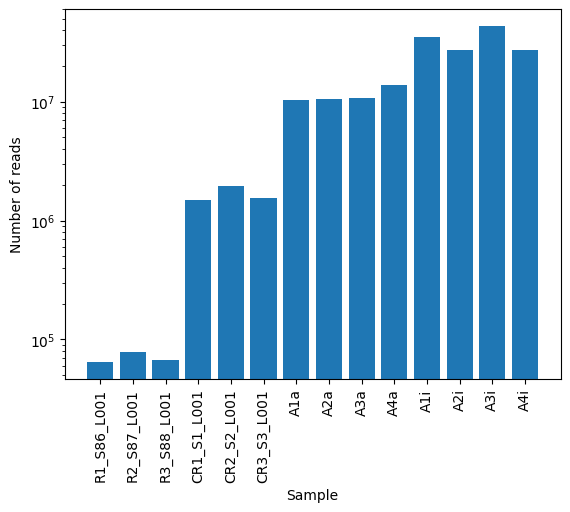

In [7]:
plt.bar([x for x in input_datasheet.index], [input_datasheet.at[x, 'raw_reads'] for x in input_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of reads')
plt.yscale('log')
#This just makes the labels on the x-axis vertical (rather than horizontal where they would probably overlap and not be readable)
plt.xticks(rotation=90);

input_datasheet

In [8]:
#Create directories
list_dir = os.listdir()

if 'logs' not in list_dir:
    os.mkdir('logs')
if 'fastqc_outputs' not in list_dir:
    os.mkdir('fastqc_outputs')
if 'pear_output' not in list_dir:
    os.mkdir('pear_output')
if 'vsearch_trim' not in list_dir:
    os.mkdir('vsearch_trim')
if 'vsearch_aggregate' not in list_dir:
    os.mkdir('vsearch_aggregate')
# If they are not already present, create directories for intermediate analysis files

## Run FastQC on samples
Change the time as a function of the number of reads. It should only take like 10 minutes. Run with sbatch run_fastqc.sh

In [9]:
# Number of samples
n_files = len(input_datasheet.index)  # This should already be defined before this block

with open('./run_fastqc.sh', 'w') as dest:

    dest.write('#!/bin/bash\n')
    dest.write('#SBATCH --nodes=1\n')
    dest.write('#SBATCH --ntasks-per-node=1\n')
    dest.write('#SBATCH --account=your-account\n')
    dest.write(f'#SBATCH --cpus-per-task={n_files + 1}\n')
    dest.write(f'#SBATCH --mem={math.ceil((n_files + 1) * 0.5)}G\n')
    dest.write('#SBATCH --time=0-00:30:00\n')
    dest.write('#SBATCH --output=logs/slurm-%j.out\n')
    dest.write('#SBATCH --mail-type=ALL\n')
    dest.write('#SBATCH --job-name=fastqc\n')
    dest.write('\n')
    
    dest.write('module load fastqc\n')
    dest.write('\n')
    
    # FastQC command now outputs into current working directory: ./fastqc_outputs
    fastqc_command = f'fastqc --outdir fastqc_outputs -t {n_files} --extract --delete data/*.fastq.gz'
    dest.write(fastqc_command)

## Trim and merge reads
Change the time as a function of the number of reads. For my ChrR library, it did everything in about 1.5h. Run with sbatch process_barcodes.sh

In [10]:
with open('./process_barcodes.sh', 'w') as dest:
    dest.write('#!/bin/bash\n')
    dest.write('#SBATCH --account=your-account\n')
    dest.write('#SBATCH --nodes=1\n')
    dest.write('#SBATCH --ntasks-per-node=1\n')
    dest.write('#SBATCH --cpus-per-task=16\n')  
    dest.write('#SBATCH --mem=5G\n')
    dest.write('#SBATCH --time=0-03:00:00\n')
    dest.write('#SBATCH --output=logs/slurm-%j.out\n')
    dest.write('#SBATCH --mail-type=ALL\n')
    dest.write('#SBATCH --job-name=merging\n')
    dest.write('\n')

    # Load software modules
    dest.write('module load StdEnv/2020\n')
    dest.write('module load pear\n')
    dest.write('module load vsearch\n\n')

    # Loop through each sample in the input_datasheet
    for sample in input_datasheet.index:
        dest.write('date\n')

        # FASTQ paths (R1 and R2)
        fastq_R1 = f'data/{sample}_R1_001.fastq.gz'
        fastq_R2 = f'data/{sample}_R2_001.fastq.gz'

        # Output file paths
        initial_trim_R1_out = f'./vsearch_trim/{sample}_R1_initial_trimmed.fastq'
        initial_trim_R2_out = f'./vsearch_trim/{sample}_R2_initial_trimmed.fastq'
        pear_out = f'./pear_output/{sample}'
        assembled_reads = f'./pear_output/{sample}.assembled.fastq'
        filter_out = f'./vsearch_trim/{sample}_final_trimmed.fastq'
        filter_rc = f'./vsearch_trim/{sample}_final_trimmed_rc.fastq'
        aggregate_fasta = f'./vsearch_aggregate/{sample}_aggregate.fasta'

        # Command definitions
        initial_trim_R1 = f'vsearch --fastx_filter {fastq_R1} --fastq_stripleft 2 --fastq_stripright 2 --fastqout {initial_trim_R1_out}\n'
        initial_trim_R2 = f'vsearch --fastx_filter {fastq_R2} --fastq_stripleft 2 --fastq_stripright 2 --fastqout {initial_trim_R2_out}\n'
       
        pear_command = f'pear -f {initial_trim_R1_out} -r {initial_trim_R2_out} -o {pear_out} -j 16 -u 0.05 -q 20 -m 330 -n 20\n'
        #-f defines the forward reads file, -r defines the reverse reads file, -o defines the output location
        #-j defines to use 16 threads for processing (should be the same as the CPUs requested at the top)
        #-u defines the maximum proportion allowed for unmerged base pairs.
        #-q specifies the quality score threshold for trimming the low quality part of a read. If the quality scores of two consecutive bases are strictly less than the specified threshold, the rest of the read will be trimmed.
        #-m maximum possible length of the assembled sequences, -n minimum possible length of the assembled sequences
       
        filter_command = f'vsearch --fastx_filter {assembled_reads} --fastq_stripleft 1 --fastq_stripright 1 --fastaout {filter_out}\n'
        #fastq_stripleft defines the position to trim from the 5' end, vice versa for fastq_stripright
        
        rc_command = f'vsearch --fastx_revcomp {filter_out} --fastaout {filter_rc}\n'
        #creates the reverse complement of the trimmed sequences
       
        aggregate_command = f'vsearch --derep_fulllength {filter_rc} --relabel seq --output {aggregate_fasta} --sizeout\n'
        #derep_fulllength removes duplicate sequences (and through this, counts how many times a sequence was duplicated, listing that numnber next to the sequence in question)

        #writes all of the variables to the output file in this order (ie. performs the jobs in this order)
        #These can be switched around. For example, you could switch them around to have trimming done first or merging done first.
        dest.write(initial_trim_R1) #first trim of F reads
        dest.write(initial_trim_R2) #first trim of R reads
        dest.write('date\n') #lists the time/date for logs
        dest.write(pear_command) #aligning and merging program
        dest.write('date\n') #lists the time/date for logs
        dest.write(filter_command) #second trimming program
        dest.write(rc_command) #creates the reverse complement of the trimmed sequences
        dest.write('date\n') #lists the time/date for logs
        dest.write(aggregate_command)
        dest.write('date\n') #lists the time/date for logs

    dest.write('date\n') #lists the time/date for logs

In [11]:
# Load datasheet again if you closed the program and came back
input_datasheet = pd.read_csv('ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

,meaning,strain,timepoint,condition,replicate,raw_reads,assembled_reads
sample,,,,,,,
R1_S86_L001,ChrRa_Plasmid1,Plasmid_A,TP0,LB,1,64704,64306
R2_S87_L001,ChrRa_Plasmid2,Plasmid_A,TP0,LB,2,78939,78395
R3_S88_L001,ChrRa_Plasmid3,Plasmid_A,TP0,LB,3,66768,66319
CR1_S1_L001,ChrRi_Plasmid1,Plasmid_I,TP0,LB,1,1486711,1482327
CR2_S2_L001,ChrRi_Plasmid2,Plasmid_I,TP0,LB,2,1941982,1936512
CR3_S3_L001,ChrRi_Plasmid3,Plasmid_I,TP0,LB,3,1544795,1540412
A1a,ChrRa_Fungal1,SC5314_A,TP0,YPD,1,10277358,10224690
A2a,ChrRa_Fungal2,SC5314_A,TP0,YPD,2,10567735,10513816
A3a,ChrRa_Fungal3,SC5314_A,TP0,YPD,3,10837769,10770419


In [ ]:
assembled_read_count = {}

for sample in input_datasheet.index:
    assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
    command = command = "grep -E -o '^@L|^@M' "+assembled_reads+" | wc -l" #make sure the lines in the assembled files actually begin with "@L or whatever"
    
    output  = subprocess.check_output(command, shell=True, text=True)
    assembled_read_count[sample] = int(output.strip('\n'))
    
input_datasheet['assembled_reads'] = pd.Series(assembled_read_count)
    
input_datasheet.to_csv('ChrR_datasheet.csv', sep=',')

In [12]:
#This just updates the input_datasheet so that you don't have to run everything before this again every time you open up the code
input_datasheet = pd.read_csv('ChrR_datasheet.csv', sep=',', index_col=0)
input_datasheet

,meaning,strain,timepoint,condition,replicate,raw_reads,assembled_reads
sample,,,,,,,
R1_S86_L001,ChrRa_Plasmid1,Plasmid_A,TP0,LB,1,64704,64306
R2_S87_L001,ChrRa_Plasmid2,Plasmid_A,TP0,LB,2,78939,78395
R3_S88_L001,ChrRa_Plasmid3,Plasmid_A,TP0,LB,3,66768,66319
CR1_S1_L001,ChrRi_Plasmid1,Plasmid_I,TP0,LB,1,1486711,1482327
CR2_S2_L001,ChrRi_Plasmid2,Plasmid_I,TP0,LB,2,1941982,1936512
CR3_S3_L001,ChrRi_Plasmid3,Plasmid_I,TP0,LB,3,1544795,1540412
A1a,ChrRa_Fungal1,SC5314_A,TP0,YPD,1,10277358,10224690
A2a,ChrRa_Fungal2,SC5314_A,TP0,YPD,2,10567735,10513816
A3a,ChrRa_Fungal3,SC5314_A,TP0,YPD,3,10837769,10770419


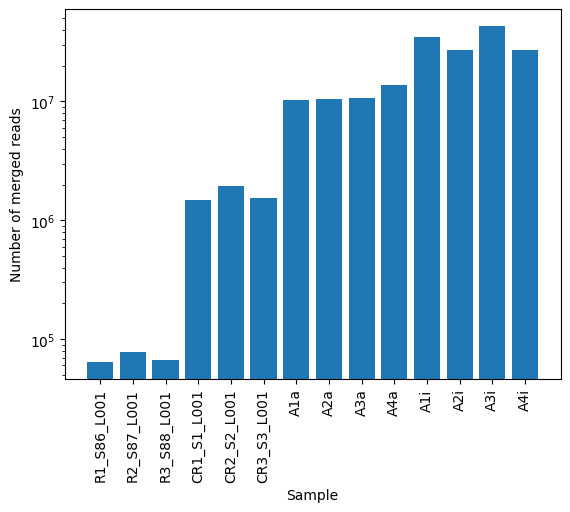

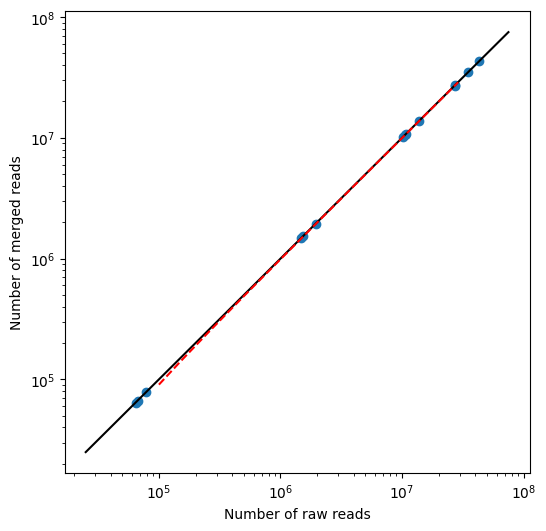

In [13]:
# Plotting the Merged Reads vs. Raw Reads
plt.bar([x for x in input_datasheet.index], [input_datasheet.at[x, 'assembled_reads'] for x in input_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of merged reads')
plt.xticks(rotation=90);
plt.yscale('log')

merge_stats = stats.linregress(input_datasheet.raw_reads, input_datasheet.assembled_reads)

plt.figure(figsize=(6,6))
plt.scatter(input_datasheet.raw_reads, input_datasheet.assembled_reads)

#this is the black line, numbers in order are low x-pos of black line, high x-pos of black line, low y-pos of black line, high y-pos of black line
plt.plot([25000, 75000000], [25000, 75000000], '-k')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Number of raw reads')
plt.ylabel('Number of merged reads')

#this is the line of best fit (dotted red line). Make sure the values in the first range statement match those in the second range statement
plt.plot(
    [x for x in range(100000, 29000000, 50000)], [(x*merge_stats[0])+merge_stats[1] for x in range(100000, 29000000, 50000)], 'r--')

## Count sgRNAs

In [3]:
#This reads your .CSV file called "sgrna_list.csv" that contains all of the sgRNAs, their sequences, and other info you want to store about them.
#The argument index_col=0 tells Pandas to use the first column as the index (i.e., row labels).
sgRNA_df = pd.read_csv('sgrna_list.csv', index_col=0)

#This, as always, just prints the dataframe here in the notebook so you can see it.
sgRNA_df

,Alias,Gene,Barcode,Position,Plasmid_A_TP0_LB_1,Plasmid_A_TP0_LB_2,Plasmid_A_TP0_LB_3,Plasmid_I_TP0_LB_1,Plasmid_I_TP0_LB_2,Plasmid_I_TP0_LB_3,SC5314_A_TP0_YPD_1,SC5314_A_TP0_YPD_2,SC5314_A_TP0_YPD_3,SC5314_A_TP0_YPD_4,SC5314_I_TP0_YPD_1,SC5314_I_TP0_YPD_2,SC5314_I_TP0_YPD_3,SC5314_I_TP0_YPD_4
Number,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,9.0,18.0,16.0,221.0,311.0,283.0,1114.0,311.0,875.0,1895.0,16729.0,25313.0,37554.0,24249.0
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,20.0,14.0,15.0,160.0,183.0,150.0,2012.0,1005.0,951.0,2942.0,1629.0,1137.0,1556.0,1056.0
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,1096.0,1369.0,1188.0,189.0,287.0,227.0,88625.0,85836.0,83113.0,116020.0,2228.0,2020.0,2223.0,1766.0
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,17.0,26.0,22.0,97.0,139.0,101.0,1967.0,751.0,1616.0,3357.0,858.0,761.0,1061.0,919.0
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,10.0,11.0,10.0,200.0,309.0,210.0,1181.0,860.0,949.0,1599.0,2033.0,1891.0,1825.0,1706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,8.0,7.0,8.0,258.0,304.0,289.0,1430.0,926.0,1185.0,1847.0,3782.0,2538.0,2825.0,2195.0
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,5.0,5.0,5.0,374.0,586.0,417.0,731.0,341.0,340.0,1290.0,6668.0,7216.0,9513.0,7227.0
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,4.0,7.0,3.0,169.0,260.0,162.0,431.0,102.0,265.0,266.0,1935.0,1399.0,1836.0,1705.0


In [4]:
#sgRNA_df.columns gives the list of column names in the DataFrame. list(sgRNA_df.columns) converts that into a regular Python list, which is stored in the new variable non_raw_cols.
non_raw_cols = list(sgRNA_df.columns)

#If that doesn't make sense, this is what the list contains. Since index_col=0 was specified when loading the CSV, the first column ("Number") is used as the index rather than being included in sgRNA_df.columns.
print(non_raw_cols)

['Alias', 'Gene', 'Barcode', 'Position', 'Plasmid_A_TP0_LB_1', 'Plasmid_A_TP0_LB_2', 'Plasmid_A_TP0_LB_3', 'Plasmid_I_TP0_LB_1', 'Plasmid_I_TP0_LB_2', 'Plasmid_I_TP0_LB_3', 'SC5314_A_TP0_YPD_1', 'SC5314_A_TP0_YPD_2', 'SC5314_A_TP0_YPD_3', 'SC5314_A_TP0_YPD_4', 'SC5314_I_TP0_YPD_1', 'SC5314_I_TP0_YPD_2', 'SC5314_I_TP0_YPD_3', 'SC5314_I_TP0_YPD_4']


### Count sgRNAs

The sgRNA counting script below is slightly different than the one used in the CRISPR screening analyses, mostly since this one cuts out the sequence in between the DNA ("anchor") that flanks the barcode and searches for the corresponding sequence in the sgRNA table, where as the CRISPR screening code basically looks for every sgRNA in every read. The one below therefore runs a lot faster, but the ultimate results should be similar.

Copy and paste the following code into a new .py file:

In [ ]:
import pandas as pd
from collections import Counter
from tqdm import tqdm

#DNA complement translation table (used for reverse-complementing)
COMP = str.maketrans("ACGTN", "TGCAN")
def revcomp(s: str) -> str: #uppercase the sequence, complement every bp, then reverse it
    s = str(s).upper()
    return s.translate(COMP)[::-1]

#Reads a FASTA file produced by vsearch --derep_fulllength --sizeout. Returns a dictionary of {header without the '>': sequence)
def get_dict_of_seq(fasta_file: str) -> dict:
    file_fasta_dict = {}
    with open(fasta_file, 'r') as fasta:
        seq_info = None
        for line in fasta:
            line = line.strip() #Remove empty space and blank lines
            if not line:
                continue
            if line.startswith('>'): #Headers
                seq_info = line[1:].split('\t')[0] #Drop the ">" and keep text only before any tab
                file_fasta_dict[seq_info] = ''
            else: #Sequences
                file_fasta_dict[seq_info] += line
    return file_fasta_dict

#Set up the counting function
def count_arrays_by_anchors(
    fasta_seq_dict: dict,
    barcode_to_sgrna: dict,
    left: str,
    right: str,
    debug_first_n_failures: int = 10
):
    left = left.upper()
    right = right.upper()
    left_rc = revcomp(right)
    right_rc = revcomp(left)
    #Store the counts for each sgRNA in the given sample
    sample_counter = Counter()
    #Track where every read ends up (every read lands in one of the last three categories)
    stats = { 
        "total_reads": 0,
        "reads_with_anchors": 0,
        "reads_matched_library": 0,
        "reads_anchor_but_not_in_library": 0,
        "reads_no_anchors": 0,
    }
    debug_printed = 0  # count unique failure occurrences
    
    #Actually loop over the reads 
    for header, seq in fasta_seq_dict.items():
        seq = seq.upper()
        try:
            seq_count = int(header.split(';size=')[1])
        except Exception:
            seq_count = 1
        stats["total_reads"] += seq_count

        # Forward orientation
        i = seq.find(left) #Return the position of the first AATTTCGA, or −1 if it isn't there
        if i != -1: #If found, the right anchor is searched for starting just after the left anchor ends
            j = seq.find(right, i + len(left))
            if j != -1:
                stats["reads_with_anchors"] += seq_count #The read is counted as having both anchors
                barcode = seq[i + len(left): j]  # forward barcode
                sgrna = barcode_to_sgrna.get(barcode) #Looks the barcode up in the library and returns the sgRNA name, or none if it doesn't match
                if sgrna is not None: #If the barcode matched an sgRNA, all of this sequence's reads are added to that sgRNA
                    sample_counter[sgrna] += seq_count
                    stats["reads_matched_library"] += seq_count
                else: #If not, reads are counted in the "anchors but not in library" category. Some examples are printed for debugging
                    stats["reads_anchor_but_not_in_library"] += seq_count
                    if debug_printed < debug_first_n_failures:
                        debug_printed += 1
                        print("\nFAIL example (forward):")
                        print("seq_count:", seq_count)
                        print("extracted barcode len:", len(barcode))
                        print("barcode:", barcode)
                        print("full seq:", seq)
                continue #Move on to the next read, regardless

        #Reverse orientation. This only runs if the forward anchors weren't both found above (same steps but with flipped anchors)
        i = seq.find(left_rc)
        if i != -1:
            j = seq.find(right_rc, i + len(left_rc))
            if j != -1:
                stats["reads_with_anchors"] += seq_count
                barcode_rc = seq[i + len(left_rc): j]     # barcode as it appears in RC read
                barcode = revcomp(barcode_rc)              # convert back to forward for matching
                sgrna = barcode_to_sgrna.get(barcode)
                if sgrna is not None:
                    sample_counter[sgrna] += seq_count
                    stats["reads_matched_library"] += seq_count
                else:
                    stats["reads_anchor_but_not_in_library"] += seq_count
                    if debug_printed < debug_first_n_failures:
                        debug_printed += 1
                        print("\nFAIL example (reverse):")
                        print("seq_count:", seq_count)
                        print("extracted barcode_rc len:", len(barcode_rc))
                        print("barcode_rc:", barcode_rc)
                        print("barcode_fwd (revcomp):", barcode)
                        print("full seq:", seq)
                continue
        #If neither orientation had both anchors, the read is counted as having no anchors
        stats["reads_no_anchors"] += seq_count
    return sample_counter, stats

#Load inputs
input_datasheet = pd.read_csv('ChrR_datasheet.csv', sep=',', index_col=0)
sgRNA_df = pd.read_csv('sgrna_list.csv', index_col=0)

#Build mapping: Barcode (uppercase, no spaces) -> sgRNA row/index
barcode_to_sgrna = {}
for sgrna, row in sgRNA_df.iterrows(): #Go through the library one row at a time. Missing/blank barcodes are skipped. Barcodes are mapped to sgRNA number
    barcode = row.get("Barcode", "")
    if pd.isna(barcode):
        continue
    barcode = str(barcode).replace(" ", "").upper()
    if barcode == "":
        continue
    barcode_to_sgrna[barcode] = sgrna

#Anchors
LEFT = "AATTTCGA"
RIGHT = "GTTTTAGA"
usable_reads_dict = {}
qc_rows = []

#Actually count samples
for sample in tqdm(input_datasheet.index, desc="Counting samples"):
    aggregate_fasta = f'./vsearch_aggregate/{sample}_aggregate.fasta'
    fasta_dict = get_dict_of_seq(aggregate_fasta)
    sgRNA_counter, stats = count_arrays_by_anchors(
        fasta_dict,
        barcode_to_sgrna=barcode_to_sgrna,
        left=LEFT,
        right=RIGHT,
        debug_first_n_failures=10  # prints first N failure *events* per sample
    )

    #Summary for logs
    print("sample:", sample)
    print("total_reads:", stats["total_reads"])
    print("reads_with_anchors:", stats["reads_with_anchors"])
    print("reads_matched_library:", stats["reads_matched_library"])
    print("reads_anchor_but_not_in_library:", stats["reads_anchor_but_not_in_library"])
    print("reads_no_anchors:", stats["reads_no_anchors"])
    
    usable_reads_dict[sample] = stats["reads_matched_library"]
    qc_rows.append({"sample": sample, **stats})
    col_name = (
        f"{input_datasheet.at[sample, 'strain']}_"
        f"{input_datasheet.at[sample, 'timepoint']}_"
        f"{input_datasheet.at[sample, 'condition']}_"
        f"{input_datasheet.at[sample, 'replicate']}"
    )
    sgRNA_df[col_name] = pd.Series(sgRNA_counter)

#Write outputs
sgRNA_df.to_csv("sgrna_list.csv", index=True)
pd.DataFrame(qc_rows).to_csv("counting_qc_stats.csv", index=False)

Then, copy the following code into a new .sh file:

In [ ]:
#!/bin/bash
#SBATCH --account=your-account
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=16
#SBATCH --mem=5G
#SBATCH --time=0-00:20:00
#SBATCH --output=logs/slurm-%j.out
#SBATCH --mail-type=ALL
#SBATCH --job-name=counting

module load scipy-stack/2023b  

python count_sgRNAs.py

Then, submit the job to SLURM to run

### Checking the Number of Counts/Dropouts and Replacing NaN Values with 0

In [5]:
#Load datasheet once again
input_datasheet = pd.read_csv('ChrR_datasheet.csv', sep=',', index_col=0)

#Re-import the sgRNA_df from the updated .csv file
sgRNA_df = pd.read_csv('sgrna_list.csv', sep=',', index_col=0)
sgRNA_df

,Alias,Gene,Barcode,Position,Plasmid_A_TP0_LB_1,Plasmid_A_TP0_LB_2,Plasmid_A_TP0_LB_3,Plasmid_I_TP0_LB_1,Plasmid_I_TP0_LB_2,Plasmid_I_TP0_LB_3,SC5314_A_TP0_YPD_1,SC5314_A_TP0_YPD_2,SC5314_A_TP0_YPD_3,SC5314_A_TP0_YPD_4,SC5314_I_TP0_YPD_1,SC5314_I_TP0_YPD_2,SC5314_I_TP0_YPD_3,SC5314_I_TP0_YPD_4
Number,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,9.0,18.0,16.0,221.0,311.0,283.0,1114.0,311.0,875.0,1895.0,16729.0,25313.0,37554.0,24249.0
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,20.0,14.0,15.0,160.0,183.0,150.0,2012.0,1005.0,951.0,2942.0,1629.0,1137.0,1556.0,1056.0
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,1096.0,1369.0,1188.0,189.0,287.0,227.0,88625.0,85836.0,83113.0,116020.0,2228.0,2020.0,2223.0,1766.0
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,17.0,26.0,22.0,97.0,139.0,101.0,1967.0,751.0,1616.0,3357.0,858.0,761.0,1061.0,919.0
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,10.0,11.0,10.0,200.0,309.0,210.0,1181.0,860.0,949.0,1599.0,2033.0,1891.0,1825.0,1706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,8.0,7.0,8.0,258.0,304.0,289.0,1430.0,926.0,1185.0,1847.0,3782.0,2538.0,2825.0,2195.0
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,5.0,5.0,5.0,374.0,586.0,417.0,731.0,341.0,340.0,1290.0,6668.0,7216.0,9513.0,7227.0
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,4.0,7.0,3.0,169.0,260.0,162.0,431.0,102.0,265.0,266.0,1935.0,1399.0,1836.0,1705.0


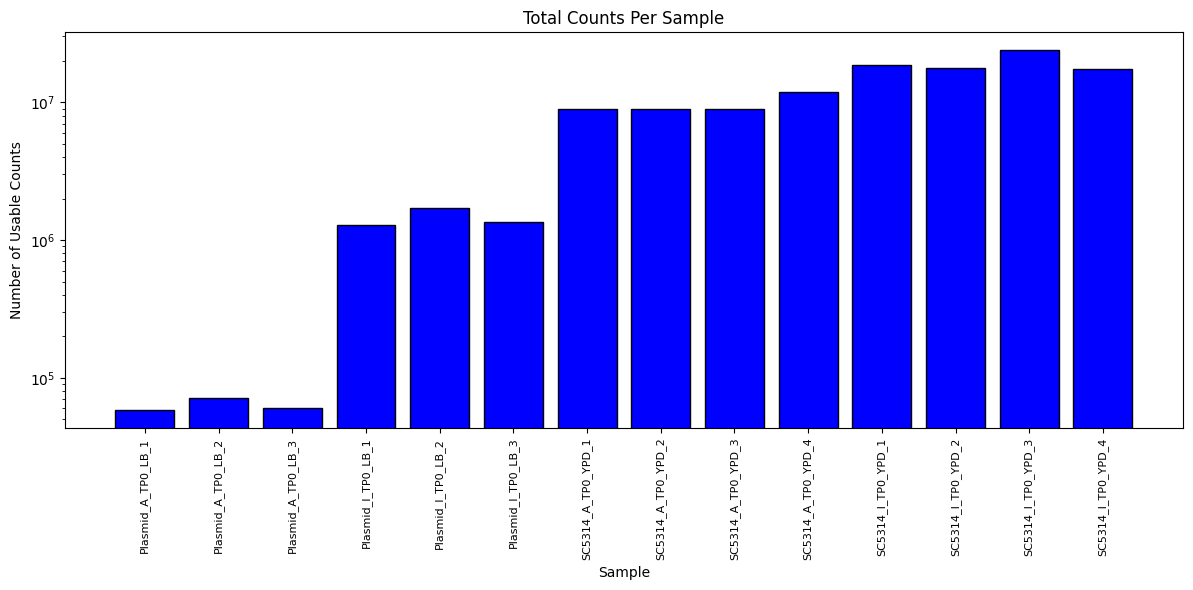

Text(0, 0.5, 'Number of usable counts')

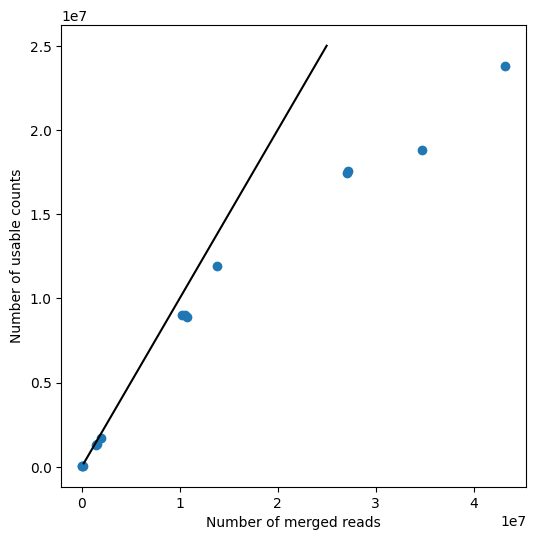

In [6]:
#Plotting the number of usable counts from each sample

#List of all sample columns
samples = [
    'Plasmid_A_TP0_LB_1', 'Plasmid_A_TP0_LB_2', 'Plasmid_A_TP0_LB_3', 'Plasmid_I_TP0_LB_1', 'Plasmid_I_TP0_LB_2', 'Plasmid_I_TP0_LB_3', 
    'SC5314_A_TP0_YPD_1', 'SC5314_A_TP0_YPD_2', 'SC5314_A_TP0_YPD_3', 'SC5314_A_TP0_YPD_4',
    'SC5314_I_TP0_YPD_1', 'SC5314_I_TP0_YPD_2', 'SC5314_I_TP0_YPD_3', 'SC5314_I_TP0_YPD_4'
]

#Calculate total counts for each sample (sum of sgRNA counts per sample)
sample_counts = sgRNA_df[samples].sum(axis=0)  # Sum across sgRNAs (rows) for each sample (columns)

#Plotting
plt.figure(figsize=(12, 6))
plt.bar(sample_counts.index, sample_counts.values, color='blue', edgecolor='black')

#Formatting the plot
plt.xticks(rotation=90, fontsize=8)
plt.title('Total Counts Per Sample')
plt.xlabel('Sample')
plt.ylabel('Number of Usable Counts')
plt.tight_layout()
plt.yscale('log')
plt.show()

#Plotting the number of usable counts vs. merged reads for each sample
plt.figure(figsize=(6,6))
plt.scatter(input_datasheet.assembled_reads, sample_counts)

plt.plot([200000, 25000000], [200000, 25000000], '-k')

plt.xlabel('Number of merged reads')
plt.ylabel('Number of usable counts')

In [7]:
#Load original file
sgRNA_df = pd.read_csv('sgrna_list.csv')

#Create a copy for processing
sgRNA_df_no_NaN = sgRNA_df.copy()

# Define the count columns
count_col_list = [
    'Plasmid_A_TP0_LB_1', 'Plasmid_A_TP0_LB_2', 'Plasmid_A_TP0_LB_3', 'Plasmid_I_TP0_LB_1', 'Plasmid_I_TP0_LB_2', 'Plasmid_I_TP0_LB_3', 
    'SC5314_A_TP0_YPD_1', 'SC5314_A_TP0_YPD_2', 'SC5314_A_TP0_YPD_3', 'SC5314_A_TP0_YPD_4',
    'SC5314_I_TP0_YPD_1', 'SC5314_I_TP0_YPD_2', 'SC5314_I_TP0_YPD_3', 'SC5314_I_TP0_YPD_4'
]

#Replace NaNs with 0
sgRNA_df_no_NaN[count_col_list] = sgRNA_df_no_NaN[count_col_list].fillna(0)

#Validate
print("NaN counts after replacement (should all be 0):")
print(sgRNA_df_no_NaN[count_col_list].isna().sum())

# Save processed version
sgRNA_df_no_NaN.to_csv('sgrna_list_no_NaN.csv', index=False)

NaN counts after replacement (should all be 0):
Plasmid_A_TP0_LB_1    0
Plasmid_A_TP0_LB_2    0
Plasmid_A_TP0_LB_3    0
Plasmid_I_TP0_LB_1    0
Plasmid_I_TP0_LB_2    0
Plasmid_I_TP0_LB_3    0
SC5314_A_TP0_YPD_1    0
SC5314_A_TP0_YPD_2    0
SC5314_A_TP0_YPD_3    0
SC5314_A_TP0_YPD_4    0
SC5314_I_TP0_YPD_1    0
SC5314_I_TP0_YPD_2    0
SC5314_I_TP0_YPD_3    0
SC5314_I_TP0_YPD_4    0
dtype: int64


In [8]:
#Show the current dataframe containing all of the information on sgRNAs and counts
sgRNA_df_no_NaN

,Number,Alias,Gene,Barcode,Position,Plasmid_A_TP0_LB_1,Plasmid_A_TP0_LB_2,Plasmid_A_TP0_LB_3,Plasmid_I_TP0_LB_1,Plasmid_I_TP0_LB_2,Plasmid_I_TP0_LB_3,SC5314_A_TP0_YPD_1,SC5314_A_TP0_YPD_2,SC5314_A_TP0_YPD_3,SC5314_A_TP0_YPD_4,SC5314_I_TP0_YPD_1,SC5314_I_TP0_YPD_2,SC5314_I_TP0_YPD_3,SC5314_I_TP0_YPD_4
0,1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,9.0,18.0,16.0,221.0,311.0,283.0,1114.0,311.0,875.0,1895.0,16729.0,25313.0,37554.0,24249.0
1,2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,20.0,14.0,15.0,160.0,183.0,150.0,2012.0,1005.0,951.0,2942.0,1629.0,1137.0,1556.0,1056.0
2,3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,1096.0,1369.0,1188.0,189.0,287.0,227.0,88625.0,85836.0,83113.0,116020.0,2228.0,2020.0,2223.0,1766.0
3,4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,17.0,26.0,22.0,97.0,139.0,101.0,1967.0,751.0,1616.0,3357.0,858.0,761.0,1061.0,919.0
4,5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,10.0,11.0,10.0,200.0,309.0,210.0,1181.0,860.0,949.0,1599.0,2033.0,1891.0,1825.0,1706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5696,5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,8.0,7.0,8.0,258.0,304.0,289.0,1430.0,926.0,1185.0,1847.0,3782.0,2538.0,2825.0,2195.0
5697,5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,5.0,5.0,5.0,374.0,586.0,417.0,731.0,341.0,340.0,1290.0,6668.0,7216.0,9513.0,7227.0
5698,5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,4.0,7.0,3.0,169.0,260.0,162.0,431.0,102.0,265.0,266.0,1935.0,1399.0,1836.0,1705.0
5699,5700,non-targeting60,non-targeting60,AGACTGAAACGGCAGCGCGA,NaN,20.0,23.0,20.0,411.0,488.0,419.0,1677.0,1456.0,1479.0,2807.0,9357.0,10322.0,13663.0,8639.0


In [9]:
#Load the sgRNA_df_no_NaN.csv file again in case you closed the program
sgRNA_df_no_NaN = pd.read_csv('sgrna_list_no_NaN.csv', index_col=0)

In [10]:
#Confirm that the samples value from before contains all of the samples in your .csv file
samples

['Plasmid_A_TP0_LB_1',
 'Plasmid_A_TP0_LB_2',
 'Plasmid_A_TP0_LB_3',
 'Plasmid_I_TP0_LB_1',
 'Plasmid_I_TP0_LB_2',
 'Plasmid_I_TP0_LB_3',
 'SC5314_A_TP0_YPD_1',
 'SC5314_A_TP0_YPD_2',
 'SC5314_A_TP0_YPD_3',
 'SC5314_A_TP0_YPD_4',
 'SC5314_I_TP0_YPD_1',
 'SC5314_I_TP0_YPD_2',
 'SC5314_I_TP0_YPD_3',
 'SC5314_I_TP0_YPD_4']

## Calculate Frequencies from Raw Counts

We are ultimately going to filter out those gRNAs that do not meet a certain frequency threshold in a given sample. We do this rather than filtering out gRNAs that were not counted at least X number of times in a given sample, for example, as the total number of counts differs between different samples. So first we calculate the frequency of each gRNA in each sample.

Remember, we add the equivalent of one count to each gRNA in each sample to calculate the frequency value (otherwise you could not actually generate a frequency), so you will still see a lot of gRNAs with a "0" in the count, but its corresponding frequency will be a value that reflects the corresponding count if it had a single extra count added to it. 

In [12]:
frequencies_df = sgRNA_df_no_NaN
frequencies_df

,Alias,Gene,Barcode,Position,Plasmid_A_TP0_LB_1,Plasmid_A_TP0_LB_2,Plasmid_A_TP0_LB_3,Plasmid_I_TP0_LB_1,Plasmid_I_TP0_LB_2,Plasmid_I_TP0_LB_3,SC5314_A_TP0_YPD_1,SC5314_A_TP0_YPD_2,SC5314_A_TP0_YPD_3,SC5314_A_TP0_YPD_4,SC5314_I_TP0_YPD_1,SC5314_I_TP0_YPD_2,SC5314_I_TP0_YPD_3,SC5314_I_TP0_YPD_4
Number,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,9.0,18.0,16.0,221.0,311.0,283.0,1114.0,311.0,875.0,1895.0,16729.0,25313.0,37554.0,24249.0
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,20.0,14.0,15.0,160.0,183.0,150.0,2012.0,1005.0,951.0,2942.0,1629.0,1137.0,1556.0,1056.0
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,1096.0,1369.0,1188.0,189.0,287.0,227.0,88625.0,85836.0,83113.0,116020.0,2228.0,2020.0,2223.0,1766.0
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,17.0,26.0,22.0,97.0,139.0,101.0,1967.0,751.0,1616.0,3357.0,858.0,761.0,1061.0,919.0
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,10.0,11.0,10.0,200.0,309.0,210.0,1181.0,860.0,949.0,1599.0,2033.0,1891.0,1825.0,1706.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,8.0,7.0,8.0,258.0,304.0,289.0,1430.0,926.0,1185.0,1847.0,3782.0,2538.0,2825.0,2195.0
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,5.0,5.0,5.0,374.0,586.0,417.0,731.0,341.0,340.0,1290.0,6668.0,7216.0,9513.0,7227.0
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,4.0,7.0,3.0,169.0,260.0,162.0,431.0,102.0,265.0,266.0,1935.0,1399.0,1836.0,1705.0


In [13]:
# Define the count columns again in case you closed the program
count_col_list = [
    'Plasmid_A_TP0_LB_1', 'Plasmid_A_TP0_LB_2', 'Plasmid_A_TP0_LB_3', 'Plasmid_I_TP0_LB_1', 'Plasmid_I_TP0_LB_2', 'Plasmid_I_TP0_LB_3', 
    'SC5314_A_TP0_YPD_1', 'SC5314_A_TP0_YPD_2', 'SC5314_A_TP0_YPD_3', 'SC5314_A_TP0_YPD_4',
    'SC5314_I_TP0_YPD_1', 'SC5314_I_TP0_YPD_2', 'SC5314_I_TP0_YPD_3', 'SC5314_I_TP0_YPD_4'
]

freq_col_list = []

#Add pseudocount of 1 to all sgRNA counts
pseudocount = 1

#Note that the pseudocount of 1 is just added during calculation, the code does not update the original columns with an extra count. 
#So the original columns still have the real counts, the frequencies were just calculated with that extra pseudocount
for col in count_col_list:
    freq_col = 'freq_' + col
    # Add pseudocount to numerator AND account for total extra counts from pseudocounts in denominator
    frequencies_df[freq_col] = (frequencies_df[col] + pseudocount) / \
                               (frequencies_df[col].sum() + pseudocount * len(frequencies_df))
    freq_col_list.append(freq_col)

frequencies_df

,Alias,Gene,Barcode,Position,Plasmid_A_TP0_LB_1,Plasmid_A_TP0_LB_2,Plasmid_A_TP0_LB_3,Plasmid_I_TP0_LB_1,Plasmid_I_TP0_LB_2,Plasmid_I_TP0_LB_3,...,freq_Plasmid_I_TP0_LB_2,freq_Plasmid_I_TP0_LB_3,freq_SC5314_A_TP0_YPD_1,freq_SC5314_A_TP0_YPD_2,freq_SC5314_A_TP0_YPD_3,freq_SC5314_A_TP0_YPD_4,freq_SC5314_I_TP0_YPD_1,freq_SC5314_I_TP0_YPD_2,freq_SC5314_I_TP0_YPD_3,freq_SC5314_I_TP0_YPD_4
Number,,,,,,,,,,,,,,,,,,,,,
1,CR07390CA_242,CR07390C_A,TGCGCACAATTTCCTGCACA,1605752.0,9.0,18.0,16.0,221.0,311.0,283.0,...,0.000183,0.000209,0.000124,0.000035,0.000099,0.000159,0.000891,0.001440,0.001577,0.001390
2,CR07390CA_276_revcom,CR07390C_A,GAGTATAGTGATCCATGTGC,1605740.0,20.0,14.0,15.0,160.0,183.0,150.0,...,0.000108,0.000111,0.000224,0.000112,0.000107,0.000246,0.000087,0.000065,0.000065,0.000061
3,CR07390CA_239_revcom,CR07390C_A,GCTATAACGTTACTAGTAGT,1605777.0,1096.0,1369.0,1188.0,189.0,287.0,227.0,...,0.000169,0.000168,0.009841,0.009537,0.009349,0.009706,0.000119,0.000115,0.000093,0.000101
4,CR07390CA_140_revcom,CR07390C_A,ATAGATGTGATTGTCTTATA,1605876.0,17.0,26.0,22.0,97.0,139.0,101.0,...,0.000082,0.000075,0.000219,0.000084,0.000182,0.000281,0.000046,0.000043,0.000045,0.000053
5,CR07390CA_212_revcom,CR07390C_A,TCCATCATCATTATTACAAT,1605804.0,10.0,11.0,10.0,200.0,309.0,210.0,...,0.000182,0.000155,0.000131,0.000096,0.000107,0.000134,0.000108,0.000108,0.000077,0.000098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5697,non-targeting57,non-targeting57,TCCCCAAGGCTGTCCCCCAA,NaN,8.0,7.0,8.0,258.0,304.0,289.0,...,0.000179,0.000213,0.000159,0.000103,0.000133,0.000155,0.000201,0.000144,0.000119,0.000126
5698,non-targeting58,non-targeting58,GACCTCTTTCGACTAGGCCA,NaN,5.0,5.0,5.0,374.0,586.0,417.0,...,0.000344,0.000307,0.000081,0.000038,0.000038,0.000108,0.000355,0.000411,0.000400,0.000414
5699,non-targeting59,non-targeting59,GCACTAGCGTCCCACGAATG,NaN,4.0,7.0,3.0,169.0,260.0,162.0,...,0.000153,0.000120,0.000048,0.000011,0.000030,0.000022,0.000103,0.000080,0.000077,0.000098


Text(0, 0.5, 'Freq')

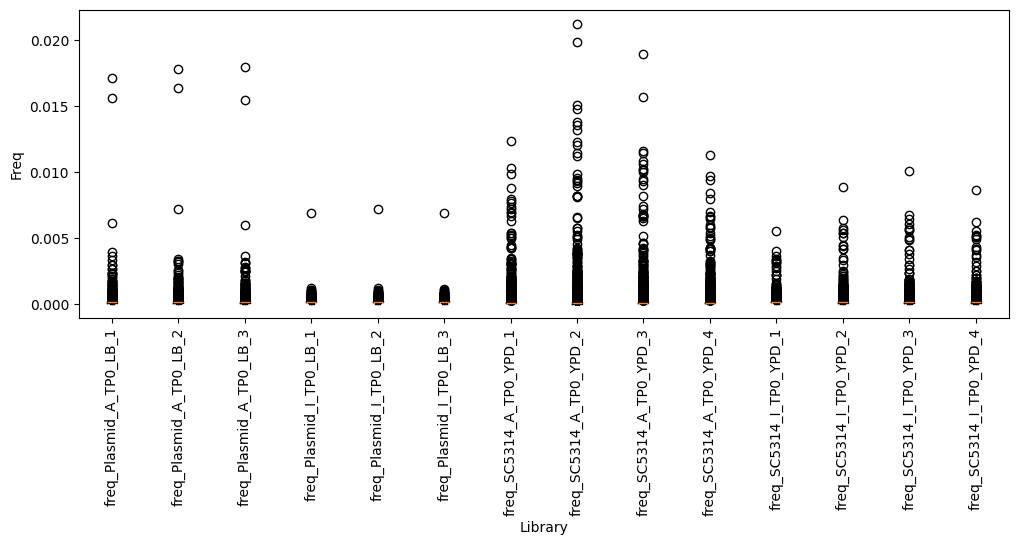

In [14]:
plt.figure(figsize=(12,4))

# let's also look at the distribution of raw abundances for each library
x=0

for col in freq_col_list:
    # print the number of reads for each library
    
    plt.boxplot(frequencies_df[col].dropna(), positions=[x])
    x+=1

plt.xticks(range(0, len(freq_col_list)), freq_col_list, rotation=90)
# label x-ticks

plt.xlabel('Library')
plt.ylabel('Freq')
# format axis labels

In [15]:
frequencies_df.to_csv("frequencies.csv")

## Generating Plots

In [16]:
# Load frequencies if not already loaded
frequencies_df = pd.read_csv('frequencies.csv', index_col=0)
# Define the four libraries and their replicate frequency columns
libraries = {
    'Plasmid_A':  ['freq_Plasmid_A_TP0_LB_1', 'freq_Plasmid_A_TP0_LB_2', 'freq_Plasmid_A_TP0_LB_3'],
    'Plasmid_I':  ['freq_Plasmid_I_TP0_LB_1', 'freq_Plasmid_I_TP0_LB_2', 'freq_Plasmid_I_TP0_LB_3'],
    'SC5314_A':   ['freq_SC5314_A_TP0_YPD_1', 'freq_SC5314_A_TP0_YPD_2', 'freq_SC5314_A_TP0_YPD_3', 'freq_SC5314_A_TP0_YPD_4'],
    'SC5314_I':   ['freq_SC5314_I_TP0_YPD_1', 'freq_SC5314_I_TP0_YPD_2', 'freq_SC5314_I_TP0_YPD_3', 'freq_SC5314_I_TP0_YPD_4'],
}
count_libraries = {
    'Plasmid_A':  ['Plasmid_A_TP0_LB_1', 'Plasmid_A_TP0_LB_2', 'Plasmid_A_TP0_LB_3'],
    'Plasmid_I':  ['Plasmid_I_TP0_LB_1', 'Plasmid_I_TP0_LB_2', 'Plasmid_I_TP0_LB_3'],
    'SC5314_A':   ['SC5314_A_TP0_YPD_1', 'SC5314_A_TP0_YPD_2', 'SC5314_A_TP0_YPD_3', 'SC5314_A_TP0_YPD_4'],
    'SC5314_I':   ['SC5314_I_TP0_YPD_1', 'SC5314_I_TP0_YPD_2', 'SC5314_I_TP0_YPD_3', 'SC5314_I_TP0_YPD_4'],
}
library_labels = {
    'Plasmid_A': 'Plasmid (CRISPRa)',
    'Plasmid_I': 'Plasmid (CRISPRi)',
    'SC5314_A':  'SC5314 (CRISPRa)',
    'SC5314_I':  'SC5314 (CRISPRi)',
}
n_sgrnas = len(frequencies_df)
print(f"Total sgRNAs in library: {n_sgrnas}")
#Compute mean frequency across replicates for each library
for lib, cols in libraries.items():
    frequencies_df[f'mean_freq_{lib}'] = frequencies_df[cols].mean(axis=1)
#Compute mean raw count across replicates for each library
sgRNA_df_no_NaN = pd.read_csv('sgrna_list_no_NaN.csv', index_col=0)
for lib, cols in count_libraries.items():
    sgRNA_df_no_NaN[f'mean_count_{lib}'] = sgRNA_df_no_NaN[cols].mean(axis=1)

#Fungal (SC5314) libraries: guide must have >= 50 raw counts in EVERY replicate.
#Plasmid libraries: guide must have >= 10 CPM in every replicate. This is just because the plasmid libraries were sequenced with older Illumina technology where you get much fewer reads
CPM_THRESHOLD = 10
COUNT_THRESHOLD = 50

def is_plasmid(lib):
    return lib.startswith('Plasmid')

dropout_results = {}
for lib, cols in count_libraries.items():
    raw = sgRNA_df_no_NaN[cols]
    if is_plasmid(lib):
        lib_cpm = raw.copy()
        for col in cols:
            lib_cpm[col] = raw[col] / raw[col].sum() * 1e6
        is_dropout = lib_cpm.min(axis=1) < CPM_THRESHOLD
        criterion = f'min replicate < {CPM_THRESHOLD} CPM'
    else:
        is_dropout = raw.min(axis=1) < COUNT_THRESHOLD
        criterion = f'min replicate < {COUNT_THRESHOLD} counts'
    n_dropouts = int(is_dropout.sum())
    dropout_results[lib] = {
        'n_dropouts': n_dropouts,
        'pct_dropouts': 100 * n_dropouts / n_sgrnas,
        'n_present': n_sgrnas - n_dropouts,
        'is_dropout': is_dropout,   # boolean mask, indexed like sgRNA_df_no_NaN
        'criterion': criterion,
    }
    print(f"{library_labels[lib]}: {n_dropouts} dropouts ({100*n_dropouts/n_sgrnas:.1f}%), "
          f"{n_sgrnas - n_dropouts} present ({100*(n_sgrnas-n_dropouts)/n_sgrnas:.1f}%) "
          f"[{criterion}]")

#All four libraries feed scoring: a guide is retained only if present in every library.
valid_gRNAs = ~pd.concat(
    [dropout_results[lib]['is_dropout'] for lib in libraries], axis=1
).any(axis=1)
print(f"\nGuides passing in all 4 libraries: {int(valid_gRNAs.sum())} / {n_sgrnas}")

Total sgRNAs in library: 5701
Plasmid (CRISPRa): 285 dropouts (5.0%), 5416 present (95.0%) [min replicate < 10 CPM]
Plasmid (CRISPRi): 10 dropouts (0.2%), 5691 present (99.8%) [min replicate < 10 CPM]
SC5314 (CRISPRa): 278 dropouts (4.9%), 5423 present (95.1%) [min replicate < 50 counts]
SC5314 (CRISPRi): 9 dropouts (0.2%), 5692 present (99.8%) [min replicate < 50 counts]

Guides passing in all 4 libraries: 5224 / 5701


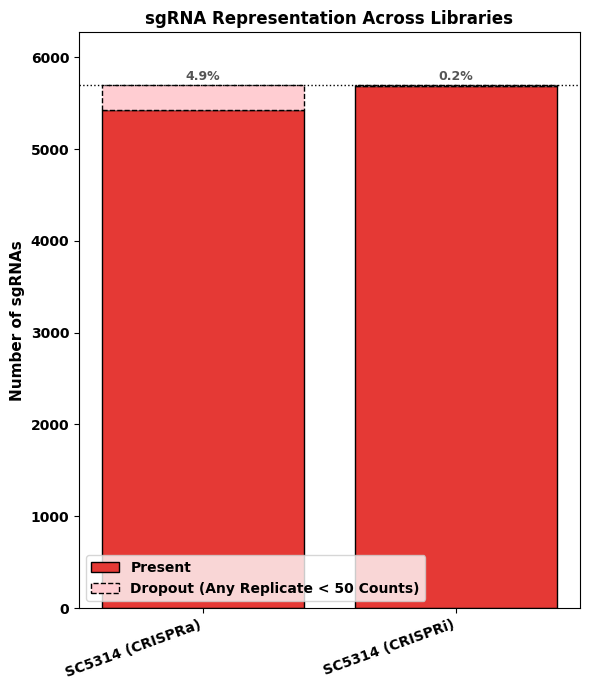

In [17]:
fig, ax = plt.subplots(figsize=(6, 7))
fungal_libs = [lib for lib in libraries if not lib.startswith('Plasmid')]
lib_names = [library_labels[lib] for lib in fungal_libs]
n_present = [dropout_results[lib]['n_present'] for lib in fungal_libs]
n_dropouts_list = [dropout_results[lib]['n_dropouts'] for lib in fungal_libs]
bars1 = ax.bar(lib_names, n_present, color='#E53935', edgecolor='black', label='Present')
bars2 = ax.bar(lib_names, n_dropouts_list, bottom=n_present, color='#FFCDD2',
               edgecolor='black', linestyle='--', label='Dropout (Any Replicate < 50 Counts)')
for i, lib in enumerate(fungal_libs):
    pct = dropout_results[lib]['pct_dropouts']
    ax.text(i, n_sgrnas + 20, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9,
            color='#555555', fontweight='bold'
           )
ax.set_ylim(0, n_sgrnas * 1.1)
ax.axhline(y=n_sgrnas, color='black', linestyle=':', linewidth=1)
ax.set_ylabel('Number of sgRNAs', fontsize=11, fontweight='bold'
             )
ax.set_title('sgRNA Representation Across Libraries', fontsize=12, fontweight='bold'
            )
ax.legend(fontsize=9, prop={'weight': 'bold'})
plt.xticks(rotation=20, ha='right', fontweight='bold'
          )
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dropouts.png', bbox_inches='tight')
plt.show()

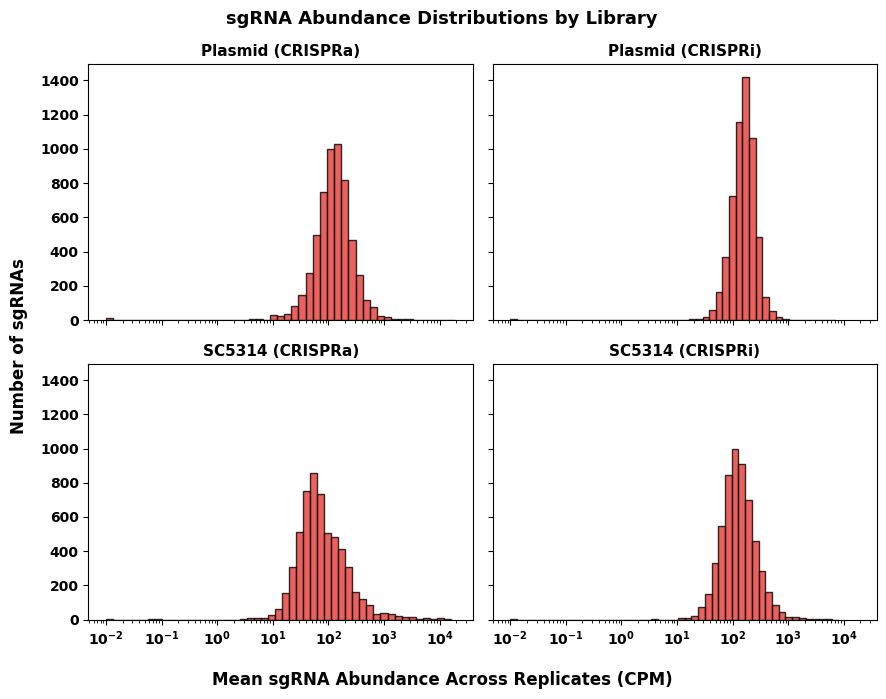

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)
axes = axes.flatten()
for ax, lib in zip(axes, libraries):
    cols = count_libraries[lib]
    lib_cpm = sgRNA_df_no_NaN[cols].copy()
    for col in cols:
        col_total = sgRNA_df_no_NaN[col].sum()
        lib_cpm[col] = sgRNA_df_no_NaN[col] / col_total * 1e6
    mean_cpm = lib_cpm.mean(axis=1)
    mean_cpm_plot = mean_cpm + 0.01
    ax.hist(
        mean_cpm_plot,
        bins=np.logspace(np.log10(0.01), np.log10(mean_cpm_plot.max()), 50),
        color='#E53935',
        edgecolor='black',
        alpha=0.8
    )
    ax.set_xscale('log')
    ax.set_title(library_labels[lib], fontsize=11, fontweight='bold')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
fig.supxlabel('Mean sgRNA Abundance Across Replicates (CPM)', fontweight='bold')
fig.supylabel('Number of sgRNAs', fontweight='bold')
fig.suptitle('sgRNA Abundance Distributions by Library', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sgrna_cpm_distributions_by_library.png', bbox_inches='tight')
plt.show()